In [ ]:
!pip install pm4py

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 28.3 MB/s eta 0:00:00
  Created wheel for intervaltree: filename=intervaltree-3.1.0-py2.py3-none-any.whl size=26097 sha256=8efba40e44e47cbe9deb0205f44b16fd43716351ab301a2410cda0365f2f8548
  Stored in directory: /root/.cache/pip/wheels/31/d7/d9/eec6891f78cac19a693bd40ecb8365d2f4613318c145ec9816
Successfully built intervaltree


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.statistics.traces.generic.log import case_statistics
from pm4py.statistics.attributes.log import get as attributes_get
from collections import Counter
import datetime
import numpy as np

# 1-Data Overview
Goal: Understand log structure and quality. Actions:  
Check case/event counts.  
List activities and their frequencies.  
Identify timestamps and attributes (e.g., CRP, Leucocytes).  
Flag missing/invalid data.

In [ ]:
from pm4py.objects.log.util import dataframe_utils
log = pm4py.read_xes('sepsis.xes')

parsing log, completed traces ::   0%|          | 0/1050 [00:00<?, ?it/s]

In [ ]:
from pm4py.objects.log.importer.xes import importer as xes_importer

# Assuming 'sepsis.xes' is your event log file
log = xes_importer.apply('sepsis.xes')

print("--- Log Structure Inspection ---")
if len(log) > 0 and len(log[0]) > 0:
    first_event = log[0][0]
    print("Structure of first event:")
    for key in first_event:
        print(f"Key: {key}, Type: {type(first_event[key])}")
else:
    print("Log is empty or first case has no events")

# Function to safely get attribute value
def get_attr(event, attr_name, default=None):
    if attr_name in event:
        return event[attr_name]
    return default

# 1. Basic log statistics
print("\n--- Basic Log Statistics ---")
print(f"Number of cases: {len(log)}")
total_events = sum(len(case) for case in log)
print(f"Total number of events: {total_events}")
print(f"Average events per case: {total_events / len(log):.2f}")

parsing log, completed traces ::   0%|          | 0/1050 [00:00<?, ?it/s]

--- Log Structure Inspection ---
Structure of first event:
Key: InfectionSuspected, Type: <class 'bool'>
Key: org:group, Type: <class 'str'>
Key: DiagnosticBlood, Type: <class 'bool'>
Key: DisfuncOrg, Type: <class 'bool'>
Key: SIRSCritTachypnea, Type: <class 'bool'>
Key: Hypotensie, Type: <class 'bool'>
Key: SIRSCritHeartRate, Type: <class 'bool'>
Key: Infusion, Type: <class 'bool'>
Key: DiagnosticArtAstrup, Type: <class 'bool'>
Key: concept:name, Type: <class 'str'>
Key: Age, Type: <class 'int'>
Key: DiagnosticIC, Type: <class 'bool'>
Key: DiagnosticSputum, Type: <class 'bool'>
Key: DiagnosticLiquor, Type: <class 'bool'>
Key: DiagnosticOther, Type: <class 'bool'>
Key: SIRSCriteria2OrMore, Type: <class 'bool'>
Key: DiagnosticXthorax, Type: <class 'bool'>
Key: SIRSCritTemperature, Type: <class 'bool'>
Key: time:timestamp, Type: <class 'datetime.datetime'>
Key: DiagnosticUrinaryCulture, Type: <class 'bool'>
Key: SIRSCritLeucos, Type: <class 'bool'>
Key: Oligurie, Type: <class 'bool'>
Key

--- Basic Log Statistics ---
Number of cases: 1050
Total number of events: 15214
Average events per case: 14.49

--- Converting log to DataFrame ---
DataFrame conversion successful!
DataFrame shape: (15214, 32)
DataFrame columns: ['InfectionSuspected', 'org:group', 'DiagnosticBlood', 'DisfuncOrg', 'SIRSCritTachypnea', 'Hypotensie', 'SIRSCritHeartRate', 'Infusion', 'DiagnosticArtAstrup', 'concept:name', 'Age', 'DiagnosticIC', 'DiagnosticSputum', 'DiagnosticLiquor', 'DiagnosticOther', 'SIRSCriteria2OrMore', 'DiagnosticXthorax', 'SIRSCritTemperature', 'time:timestamp', 'DiagnosticUrinaryCulture', 'SIRSCritLeucos', 'Oligurie', 'DiagnosticLacticAcid', 'lifecycle:transition', 'Diagnose', 'Hypoxie', 'DiagnosticUrinarySediment', 'DiagnosticECG', 'case:concept:name', 'Leucocytes', 'CRP', 'LacticAcid']

First 5 rows of the DataFrame:
  InfectionSuspected org:group DiagnosticBlood DisfuncOrg SIRSCritTachypnea  \
0               True         A            True       True              True   
1     

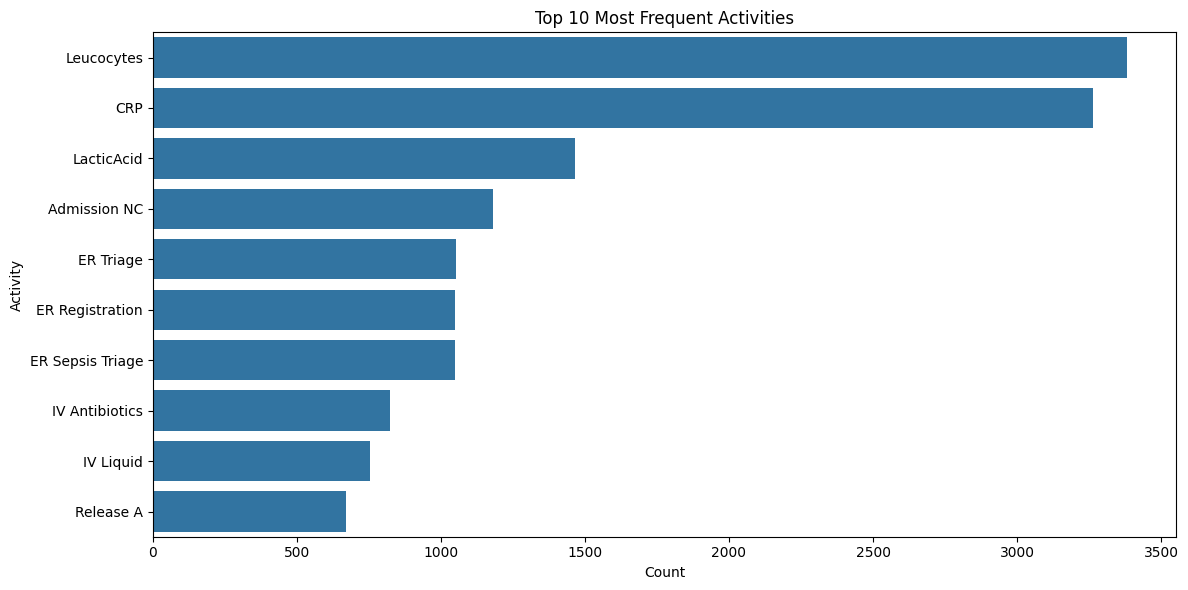


--- Case Duration Analysis ---
Number of cases with duration data: 1050
Min duration: 0.03 hours
Max duration: 10135.77 hours
Mean duration: 683.26 hours
Median duration: 128.24 hours

--- Clinical Parameters Found ---
Clinical columns: ['Leucocytes', 'CRP']


In [ ]:
# Print basic log statistics
print("--- Basic Log Statistics ---")
print(f"Number of cases: {len(log)}")
total_events = sum(len(case) for case in log)
print(f"Total number of events: {total_events}")
print(f"Average events per case: {total_events / len(log):.2f}")

# Try to convert log to dataframe (most reliable method)
try:
    # Convert log to dataframe
    print("\n--- Converting log to DataFrame ---")
    df = pm4py.convert_to_dataframe(log)
    print("DataFrame conversion successful!")
    print(f"DataFrame shape: {df.shape}")
    print("DataFrame columns:", df.columns.tolist())

    # Display first few rows
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())

    # Activity frequency analysis using DataFrame
    print("\n--- Activity Frequencies ---")
    activity_counts = df['concept:name'].value_counts().reset_index()
    activity_counts.columns = ['Activity', 'Count']
    activity_counts['Percentage'] = activity_counts['Count'] / len(df) * 100
    print(activity_counts.head(10))

    # Visualize activity frequencies
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Count', y='Activity', data=activity_counts.head(10))
    plt.title('Top 10 Most Frequent Activities')
    plt.tight_layout()
    plt.show()

    # Case duration analysis
    print("\n--- Case Duration Analysis ---")
    case_durations = df.groupby('case:concept:name').apply(
        lambda x: (x['time:timestamp'].max() - x['time:timestamp'].min()).total_seconds() / 3600
    )

    print(f"Number of cases with duration data: {len(case_durations)}")
    print(f"Min duration: {case_durations.min():.2f} hours")
    print(f"Max duration: {case_durations.max():.2f} hours")
    print(f"Mean duration: {case_durations.mean():.2f} hours")
    print(f"Median duration: {case_durations.median():.2f} hours")

    # Check for clinical parameters
    clinical_columns = [col for col in df.columns if col in ['CRP', 'Leucocytes']]
    if clinical_columns:
        print("\n--- Clinical Parameters Found ---")
        print("Clinical columns:", clinical_columns)

except Exception as e:
    print(f"Error converting log to DataFrame: {e}")
    print("Trying alternative approach with direct log access...")

    # Try to analyze directly from log structure
    try:
        # Manually print the first case structure
        first_case = log[0]
        first_event = first_case[0]
        print("\nFirst case ID:", first_case.attributes.get("concept:name", "Unknown"))
        print("First event keys:", list(first_event.keys()))

        # Try to count activities manually
        activities = Counter()
        for case in log:
            for event in case:
                # Try different attribute access methods
                try:
                    activity = event["concept:name"]
                except (TypeError, KeyError):
                    try:
                        activity = event.get("concept:name", "Unknown")
                    except:
                        activity = "Unknown"
                activities[activity] += 1

        print("\n--- Top Activities ---")
        for activity, count in activities.most_common(10):
            print(f"{activity}: {count} ({count/total_events*100:.2f}%)")

    except Exception as e2:
        print(f"Alternative approach also failed: {e2}")
        print("Please inspect your log structure manually to determine the correct access method.")

# 2-Data Cleaning & Transformation
Goal: Fix structural issues (e.g., lab tests as events). Actions:  
Reclassify lab tests (CRP, Leucocytes) as event attributes, not activities.  
Merge redundant activities (e.g., Release A/B/C → Discharge).  
Handle missing timestamps/attributes.  

In [ ]:
# Load your DataFrame (replace this with your actual DataFrame if needed)
# df = pd.read_csv('your_cleaned_data.csv')  # Uncomment if loading from file

### 1. Reclassify Lab Tests as Event Attributes ###
print("Reclassifying lab tests...")

# Create new columns for lab test metadata
df['LabTestType'] = np.nan
df['LabResult'] = np.nan

# Map lab test events to attributes
lab_tests = ['Leucocytes', 'CRP', 'LacticAcid']
for test in lab_tests:
    # Identify lab test events
    mask = df['concept:name'] == test
    # Populate new columns
    df.loc[mask, 'LabTestType'] = test
    df.loc[mask, 'LabResult'] = df.loc[mask, test]
    # Reclassify activity name
    df.loc[mask, 'concept:name'] = 'Lab Test'

# Drop original lab value columns
df.drop(columns=lab_tests, inplace=True)

# Verify changes
print(f"Lab tests reclassified. New activity counts for 'Lab Test': {len(df[df['concept:name'] == 'Lab Test'])}")

### 2. Merge Redundant Activities ###
print("\nMerging redundant activities...")
release_activities = ['Release A', 'Release B', 'Release C']
df['concept:name'] = df['concept:name'].replace(release_activities, 'Discharge')

# Verify changes
print(f"Merged {len(release_activities)} release activities into 'Discharge'")

### 3. Handle Missing Data ###
print("\nHandling missing data...")

# Timestamp validation
missing_timestamps = df['time:timestamp'].isnull().sum()
if missing_timestamps > 0:
    print(f"Warning: {missing_timestamps} events have missing timestamps. Dropping these events.")
    df = df.dropna(subset=['time:timestamp'])

# Optional: Forward-fill missing case attributes (e.g., Diagnose)
df['Diagnose'] = df.groupby('case:concept:name')['Diagnose'].ffill()

# Check final missing values
print("\nMissing values after cleaning:")
print(df.isnull().sum())

### 4. Final Validation ###
print("\nFinal DataFrame structure:")
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("\nSample of cleaned data:")
print(df[['concept:name', 'LabTestType', 'LabResult', 'Diagnose']].head(10))

# Save cleaned data for next steps
df.to_csv('sepsis_cleaned.csv', index=False)
print("\nCleaned data saved to 'sepsis_cleaned.csv'")

Reclassifying lab tests...
Lab tests reclassified. New activity counts for 'Lab Test': 8111

Merging redundant activities...
Merged 3 release activities into 'Discharge'

Handling missing data...

Missing values after cleaning:
InfectionSuspected           14164
org:group                        0
DiagnosticBlood              14164
DisfuncOrg                   14164
SIRSCritTachypnea            14164
Hypotensie                   14164
SIRSCritHeartRate            14164
Infusion                     14164
DiagnosticArtAstrup          14164
concept:name                     0
Age                          14164
DiagnosticIC                 14164
DiagnosticSputum             14164
DiagnosticLiquor             14164
DiagnosticOther              14164
SIRSCriteria2OrMore          14164
DiagnosticXthorax            14164
SIRSCritTemperature          14164
time:timestamp                   0
DiagnosticUrinaryCulture     14164
SIRSCritLeucos               14164
Oligurie                     14164
Di

/usr/local/lib/python3.11/dist-packages/cudf/pandas/fast_slow_proxy.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Leucocytes' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  return fn(*args, **kwargs)


# 3-Variant Analysis & Filtering
Goal: Identify common/rare pathways. Actions:  
Calculate case variants (unique sequences of activities).  
Filter short/long cases (e.g., remove cases with <3 events).  
Compare survivors vs. non-survivors.

In [ ]:
!pip install -U pm4py  # Ensure latest version (≥2.7.0)

import pandas as pd
from pm4py import get_variants, filter_case_size, filter_case_performance
from pm4py.visualization.dfg import visualizer as dfg_visualizer
from pm4py.util import constants

# Load cleaned data and ensure timestamp conversion
df = pd.read_csv('sepsis_cleaned.csv')  # Replace with your file path

# Critical data validation steps
print("Validating data integrity...")
if 'case:concept:name' not in df.columns:
    raise ValueError("Missing case ID column 'case:concept:name'")

if df['case:concept:name'].isnull().any():
    print("Warning: Found missing case IDs - dropping affected events")
    df = df.dropna(subset=['case:concept:name'])

# Convert timestamp column to datetime (critical for PM4Py)
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

### 1. Calculate Case Variants ###
print("\n--- Variant Analysis ---")
variants = get_variants(df,
                       activity_key='concept:name',
                       case_id_key='case:concept:name')

# Show top 5 variants
print(f"Total variants: {len(variants)}")
print("\nTop 5 most frequent variants:")
variant_counts = [(variant, count) for variant, count in variants.items()]
variant_counts.sort(key=lambda x: -x[1])
for i, (variant, count) in enumerate(variant_counts[:5]):
    print(f"{i+1}. Count: {count} | Variant: {' → '.join(variant)}")

### 2. Filter Cases by Length ###
print("\n--- Filtering Cases ---")
min_events = 3

# Filter by case size
df_filtered = filter_case_size(df,
                              min_size=min_events,
                              max_size=1000000,
                              case_id_key=constants.CASE_CONCEPT_NAME)

print(f"Filtered cases with <{min_events} events:")
print(f"Original cases: {df['case:concept:name'].nunique()}")
print(f"Filtered cases: {df_filtered['case:concept:name'].nunique()}")

### 3. Add Duration Filtering ###
print("\n--- Duration Filtering ---")

# Calculate case durations in hours
case_durations = df_filtered.groupby('case:concept:name').apply(
    lambda x: (x['time:timestamp'].max() - x['time:timestamp'].min()).total_seconds() / 3600
)

# Calculate statistical thresholds (IQR method)
Q1 = case_durations.quantile(0.25)
Q3 = case_durations.quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(Q1 - 1.5 * IQR, 0)  # No negative durations
upper_bound = Q3 + 1.5 * IQR

# Convert to seconds for PM4Py
min_duration = lower_bound * 3600
max_duration = upper_bound * 3600

# Apply duration filter
df_filtered_duration = filter_case_performance(
    df_filtered,
    min_performance=min_duration,
    max_performance=max_duration,
    case_id_key=constants.CASE_CONCEPT_NAME
)

# Save filtered data to new CSV
df_filtered_duration.to_csv('sepsis_cleaned_filtered.csv', index=False)
print("\nFiltered data saved to 'sepsis_cleaned_filtered.csv'")

print(f"Duration filter applied (IQR method):")
print(f"Original filtered cases: {df_filtered['case:concept:name'].nunique()}")
print(f"Cases after duration filtering: {df_filtered_duration['case:concept:name'].nunique()}")

### 4. Compare Survivors vs Non-Survivors ###
print("\n--- Survival Analysis ---")
survivors = df_filtered_duration[df_filtered_duration['Diagnose'] == 'A']
non_survivors = df_filtered_duration[df_filtered_duration['Diagnose'] != 'A']

def analyze_group(group, name):
    print(f"\n{name} (n={group['case:concept:name'].nunique()}):")
    group_variants = get_variants(group,
                                 activity_key='concept:name',
                                 case_id_key='case:concept:name')
    print(f"Unique variants: {len(group_variants)}")
    if group_variants:
        top_variant = next(iter(group_variants.items()))
        print(f"Most frequent variant (count {top_variant[1]}): {' → '.join(top_variant[0])}")

analyze_group(survivors, "Survivors")
analyze_group(non_survivors, "Non-Survivors")

### 5. Visualize Process Differences ###
print("\n--- Process Visualization ---")
# Generate DFG for survivors
dfg_survivors, sa, ea = pm4py.discover_dfg(survivors,
                                          activity_key='concept:name',
                                          case_id_key='case:concept:name',
                                          timestamp_key='time:timestamp')
gviz_survivors = dfg_visualizer.apply(dfg_survivors)
dfg_visualizer.save(gviz_survivors, "dfg_survivors.png")

# Generate DFG for non-survivors
dfg_non_survivors, sa, ea = pm4py.discover_dfg(non_survivors,
                                             activity_key='concept:name',
                                             case_id_key='case:concept:name',
                                             timestamp_key='time:timestamp')
gviz_non_survivors = dfg_visualizer.apply(dfg_non_survivors)
dfg_visualizer.save(gviz_non_survivors, "dfg_non_survivors.png")

print("Process maps saved as 'dfg_survivors.png' and 'dfg_non_survivors.png'")

Validating data integrity...

--- Variant Analysis ---
Total variants: 615

Top 5 most frequent variants:
1. Count: 47 | Variant: ER Registration → ER Triage → ER Sepsis Triage → Lab Test → Lab Test
2. Count: 41 | Variant: ER Registration → ER Triage → ER Sepsis Triage → Lab Test → Lab Test → Lab Test → IV Liquid → IV Antibiotics
3. Count: 35 | Variant: ER Registration → ER Triage → ER Sepsis Triage
4. Count: 23 | Variant: ER Registration → ER Triage → ER Sepsis Triage → Lab Test → Lab Test → Lab Test
5. Count: 21 | Variant: ER Registration → ER Triage → ER Sepsis Triage → Lab Test → Lab Test → Lab Test → IV Liquid → IV Antibiotics → Admission NC → Lab Test → Lab Test → Discharge

--- Filtering Cases ---
Filtered cases with <3 events:
Original cases: 1049
Filtered cases: 1049

--- Duration Filtering ---

Filtered data saved to 'sepsis_cleaned_filtered.csv'
Duration filter applied (IQR method):
Original filtered cases: 1049
Cases after duration filtering: 874

--- Survival Analysis ---


/usr/local/lib/python3.11/dist-packages/cudf/pandas/fast_slow_proxy.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return fn(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/cudf/pandas/fast_slow_proxy.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return fn(*args, **kwargs)


Process maps saved as 'dfg_survivors.png' and 'dfg_non_survivors.png'


# 4-Process Discovery
Goal: Visualize sepsis workflows. Actions:  
Generate process maps (Petri nets, BPMN).  
Mine frequent patterns (e.g., ER Triage → IV Antibiotics).  
Check bottlenecks (e.g., delays in antibiotics administration).  

In [ ]:
!pip install -U pm4py  # Ensure latest version (≥2.7.0)

import pandas as pd
import numpy as np
from pm4py.algo.discovery.inductive import algorithm as inductive_miner
from pm4py.objects.conversion.process_tree import converter as pt_converter
from pm4py.visualization.petri_net import visualizer as pn_visualizer
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualizer
from pm4py.util import constants

# Load duration-filtered data
df = pd.read_csv('sepsis_cleaned_filtered.csv')  # Ensure this file exists
df['time:timestamp'] = pd.to_datetime(df['time:timestamp'])

### 1. Generate Process Models ###
print("\n--- Process Model Discovery ---")
process_tree = inductive_miner.apply(df)
net, im, fm = pt_converter.apply(process_tree)

# Save Petri Net visualization
print("Saving Petri Net...")
gviz_pn = pn_visualizer.apply(net, im, fm)
pn_visualizer.save(gviz_pn, "petri_net.png")

### 2. Mine Frequent Patterns ###
print("\n--- Frequent Pattern Analysis ---")
dfg = dfg_discovery.apply(df, parameters={
    constants.PARAMETER_CONSTANT_ACTIVITY_KEY: 'concept:name',
    constants.PARAMETER_CONSTANT_CASEID_KEY: 'case:concept:name',
    constants.PARAMETER_CONSTANT_TIMESTAMP_KEY: 'time:timestamp'
})

# Save DFG visualization
print("Saving DFG...")
gviz_dfg = dfg_visualizer.apply(dfg,
                               activities_count=df['concept:name'].value_counts().to_dict(),
                               variant=dfg_visualizer.Variants.FREQUENCY)
dfg_visualizer.save(gviz_dfg, "dfg_frequent.png")

# Show top 5 activity pairs
print("\nTop 5 frequent activity pairs:")
activity_pairs = [(f"{a} → {b}", count) for (a, b), count in dfg.items()]
activity_pairs.sort(key=lambda x: -x[1])
for pair, count in activity_pairs[:5]:
    print(f"{pair}: {count}")

### 3. Bottleneck Analysis ###
print("\n--- Bottleneck Detection ---")

# Calculate ER Triage → IV Antibiotics delays
def calculate_delay(df, source, target):
    delays = []
    for case, group in df.groupby('case:concept:name'):
        events = group.sort_values('time:timestamp')
        path = list(events['concept:name'])
        if source in path and target in path:
            src_time = events[events['concept:name'] == source]['time:timestamp'].values[0]
            tgt_time = events[events['concept:name'] == target]['time:timestamp'].values[0]
            delays.append((tgt_time - src_time).total_seconds())
    return delays

delays = calculate_delay(df, 'ER Triage', 'IV Antibiotics')

if delays:
    median_delay = np.median(delays) / 3600
    max_delay = max(delays) / 3600
    long_delays = sum(1 for d in delays if d > 24*3600)
    print(f"Median delay: {median_delay:.2f} hours")
    print(f"Max delay: {max_delay:.2f} hours")
    print(f"Cases with >24h delay: {long_delays}")
else:
    print("No valid cases found for this pathway")

print("\nAll visualizations saved as PNG files")


--- Process Model Discovery ---
Saving Petri Net...

--- Frequent Pattern Analysis ---
Saving DFG...

Top 5 frequent activity pairs:
Lab Test → Lab Test: 4476
ER Registration → ER Triage: 808
ER Triage → ER Sepsis Triage: 755
Admission NC → Lab Test: 621
ER Sepsis Triage → Lab Test: 503

--- Bottleneck Detection ---


AttributeError: 'numpy.timedelta64' object has no attribute 'total_seconds'